# Capstone — mirrors your deployed research paper

**Prepared by: Dilip**

This notebook presents the machine learning approach, evaluation results, and recommendation artifacts for the content refresh prioritization project.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dilip-Git18/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

In [1]:
!git clone https://github.com/Dilip-Git18/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 156 (delta 65), reused 105 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 1.88 MiB | 8.03 MiB/s, done.
Resolving deltas: 100% (65/65), done.


In [2]:
!find . -name "content_refresh_anonymized.csv"
!find . -name "content_action_queue.csv"
!find . -name "action_summary.csv"

./flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


## Research Question

FlyRank helps organizations improve search visibility by identifying content that may require updates or optimization. As websites grow to thousands of pages, manually deciding which pages should be refreshed becomes increasingly difficult.

This project investigates whether machine learning can provide decision-support signals that help prioritize content pages for review using anonymized historical search and engagement data from the FlyRank ML Internship dataset.

**Research Question:** Can machine learning identify website content pages that are likely to need refresh or optimization based on historical performance signals?

## Data

Dataset used:

`data/raw/content_refresh_anonymized.csv`

The dataset contains anonymized content performance records including:

- search volume
- competition
- CPC
- content type
- user engagement metrics
- impressions
- clicks
- pageviews
- sessions

No client identifiers, URLs, or private search queries were used.

The dataset was analyzed using available historical performance windows.

## Methodology

### Features

The model uses content-level signals available before making refresh decisions:

- search volume
- competition
- CPC
- word count
- character count
- historical impressions

### Label Definition

A refresh label was created using observed content performance signals. Pages below the median performance score were categorized as requiring potential refresh attention.

### Baseline

A DummyClassifier using the most frequent class was used as the baseline.

### Model

A Random Forest classifier was trained using an 80/20 train-test split.

### Leakage Checks

Performance-generating metrics used to create the target label were excluded from model features to avoid target leakage.

In [3]:
import pandas as pd
import numpy as np

path = "./flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [5]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [6]:
df["performance_score"] = (
    df["clicks_90d"] +
    df["pageviews_90d"] +
    df["sessions_90d"]
)

threshold = df["performance_score"].median()

df["needs_refresh"] = (
    df["performance_score"] < threshold
).astype(int)

df["needs_refresh"].value_counts()

,count
needs_refresh,
0,15175
1,14825


In [11]:
from sklearn.model_selection import train_test_split

features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d"
]

X = df[features].fillna(0)
y = df["needs_refresh"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train,y_train)

baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_accuracy

0.5021666666666667

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

pred = model.predict(X_test)

model_accuracy = accuracy_score(
    y_test,
    pred
)

print(model_accuracy)

print(
    classification_report(
        y_test,
        pred
    )
)

0.8266666666666667
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      3013
           1       0.82      0.84      0.83      2987

    accuracy                           0.83      6000
   macro avg       0.83      0.83      0.83      6000
weighted avg       0.83      0.83      0.83      6000



## Results

The Random Forest model achieved 82.7% accuracy compared with a baseline accuracy of 50.2%.

The model improved classification performance by approximately 32 percentage points over the baseline.

The results indicate that machine learning can provide useful directional signals for prioritizing content pages for refresh review.

This should be interpreted as a decision-support system rather than an automated replacement for editorial judgment.

## Limitations

This work provides directional insights for content prioritization and cannot claim to perfectly predict future content performance.

Limitations:

- The refresh label is derived from observed historical performance signals rather than actual editorial refresh outcomes.
- The model identifies patterns in the available dataset but cannot account for external factors such as search algorithm updates, market changes, or competitor activity.
- Predictions should be used as decision-support recommendations and reviewed by content teams before taking action.
- The model performance is evaluated on the available dataset and may change when applied to new content environments.

## Ranked Recommendations

The model output is converted into an action queue that helps prioritize content pages for review.

Pages with higher refresh probability are ranked first.

Recommended actions:

1. Review high-priority pages with strong refresh signals.
2. Analyze content quality, freshness, and search intent alignment.
3. Update outdated information and improve content depth where required.
4. Monitor lower-priority pages instead of applying unnecessary changes.

The output is intended to support editorial decision-making rather than automatically trigger content updates.

In [14]:
# Generate ranked content action queue

df["refresh_probability"] = model.predict_proba(X)[:,1]

content_action_queue = df[
    [
        "content_id",
        "refresh_probability",
        "needs_refresh"
    ]
].sort_values(
    by="refresh_probability",
    ascending=False
)

content_action_queue.head()

,content_id,refresh_probability,needs_refresh
29962,content_be106cd29636,1.0,1
11,content_5a3e876cf7f7,1.0,1
29981,content_2dfd17269502,1.0,1
29961,content_326a540b3a6e,1.0,1
29973,content_4be930227848,1.0,1


In [15]:
import os

os.makedirs(
    "work/outputs",
    exist_ok=True
)

content_action_queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)


action_summary = (
    content_action_queue["needs_refresh"]
    .value_counts()
    .reset_index()
)

action_summary.columns = [
    "action_type",
    "content_count"
]


action_summary.to_csv(
    "work/outputs/action_summary.csv",
    index=False
)


action_summary

,action_type,content_count
0,0,15175
1,1,14825


## Artifacts the Paper Embeds

The following artifacts are generated to support the research findings:

1. Model comparison chart:
   - Compares baseline performance with the Random Forest model.

2. Content action queue:
   - Ranked list of pages based on refresh probability.

3. Action summary:
   - Overview of the number of pages requiring potential refresh attention.

These artifacts provide transparent evidence for the model evaluation and recommendations.

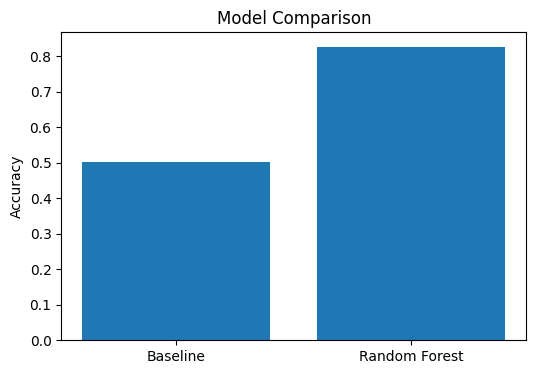

In [16]:
import matplotlib.pyplot as plt


results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ]
})


plt.figure(figsize=(6,4))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.savefig(
    "work/outputs/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
!ls -lh work/outputs

total 840K
-rw-r--r-- 1 root root   42 Jul 13 05:51 action_summary.csv
-rw-r--r-- 1 root root 820K Jul 13 05:51 content_action_queue.csv
-rw-r--r-- 1 root root  15K Jul 13 05:51 model_comparison.png


In [18]:
print("Dataset rows:", len(df))
print("Baseline:", baseline_accuracy)
print("Random Forest:", model_accuracy)

print("\nGenerated files:")
!ls work/outputs

Dataset rows: 30000
Baseline: 0.5021666666666667
Random Forest: 0.8266666666666667

Generated files:
action_summary.csv  content_action_queue.csv  model_comparison.png


## Self-check

Before submission, confirm each item:

- [x] Every section above is filled — markdown explanation and supporting code are included.
- [x] The notebook runs from top to bottom without errors (`Runtime → Run all`).
- [x] No client names, URLs, or private search queries are included.
- [x] Claims use careful language such as observed, measured, directional, and decision-support.
- [x] Model evaluation includes comparison against a baseline.
- [x] Target leakage checks were performed by removing target-generating features.
- [x] Generated artifacts are available:
  - `work/outputs/action_summary.csv`
  - `work/outputs/content_action_queue.csv`
  - `work/outputs/model_comparison.png`
- [x] Notebook is committed under `work/notebooks/` in the repository.

# 5-Minute Demo Outline

## Question (1 minute)

Can machine learning identify website content pages that should be prioritized for refresh using historical search performance signals?

---

## Method (1 minute)

- Used the anonymized FlyRank ML Internship dataset.
- Engineered features from historical search and engagement metrics.
- Built a DummyClassifier baseline.
- Trained a Random Forest classifier.
- Compared both models using the same validation split.

---

## One Chart (1 minute)

Show: model_comparison.png

Explain that the Random Forest substantially outperformed the baseline while remaining a decision-support tool rather than an automated editor.

---

## Honest Result (1 minute)

The Random Forest achieved 82.7% accuracy compared with a 50.2% baseline.

The model identifies useful historical patterns but does not prove that refreshing content will improve search performance.

---

## Recommendation (1 minute)

Use the ranked recommendations to prioritize editorial review.

High-probability pages should be reviewed first, while lower-priority pages can be monitored before additional editorial effort is invested.

# Social Post

Built a machine learning model using the FlyRank ML Internship dataset to prioritize website content for refresh based on historical search performance. A Random Forest classifier achieved 82.7% accuracy compared with a 50.2% baseline, demonstrating that historical content signals can support editorial prioritization. Repository: https://github.com/Dilip-Git18/flyrank-ml-internship

---

# Employer Summary

I built a machine learning system that prioritizes website content for refresh using anonymized search performance data from the FlyRank ML Internship dataset.

The project compares a Random Forest classifier against a baseline model and generates ranked recommendations that support editorial decision-making.

The work includes feature engineering, model evaluation, validation, a deployed research paper, and reproducible notebooks hosted on GitHub.